Realworld Healthcare Operation data are HIPPA protected so for this we have generated a synthetic HCO dataset that will mirror all the relative features used for this problem statement.

In [6]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000

data = pd.DataFrame({
    "age": np.random.randint(18, 85, n),
    "tenure_months": np.random.randint(1, 120, n),
    "outpatient_visits": np.random.poisson(5, n),
    "inpatient_admissions": np.random.poisson(1, n),
    "emergency_visits": np.random.poisson(2, n),
    "chronic_conditions": np.random.randint(0, 5, n),
    "pharmacy_cost": np.random.normal(3000, 1200, n).clip(200),
    "wellness_program": np.random.binomial(1, 0.4, n),
    "late_payments": np.random.poisson(1, n)
})

# Target variable with noise
data["annual_claim_cost"] = (
    data["age"] * 40 +
    data["outpatient_visits"] * 300 +
    data["inpatient_admissions"] * 5000 +
    data["emergency_visits"] * 1200 +
    data["chronic_conditions"] * 4000 +
    data["pharmacy_cost"] -
    data["wellness_program"] * 800 +
    np.random.normal(0, 2000, n)
)

data.head()


,age,tenure_months,outpatient_visits,inpatient_admissions,emergency_visits,chronic_conditions,pharmacy_cost,wellness_program,late_payments,annual_claim_cost
0,69,75,10,0,2,0,2246.002998,1,3,10542.833715
1,32,70,2,0,2,1,2759.719998,0,0,9339.976655
2,78,18,5,2,3,3,5036.267783,0,0,35485.034734
3,38,85,3,1,4,2,5388.035416,0,1,26354.926127
4,41,42,8,0,2,0,406.366689,0,1,8782.718995


#### Importing necessary libraries and packages

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

#### Exploratory Data Analysis

In [10]:
## shape of the data
data.shape

(1000, 10)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   tenure_months         1000 non-null   int64  
 2   outpatient_visits     1000 non-null   int64  
 3   inpatient_admissions  1000 non-null   int64  
 4   emergency_visits      1000 non-null   int64  
 5   chronic_conditions    1000 non-null   int64  
 6   pharmacy_cost         1000 non-null   float64
 7   wellness_program      1000 non-null   int64  
 8   late_payments         1000 non-null   int64  
 9   annual_claim_cost     1000 non-null   float64
dtypes: float64(2), int64(8)
memory usage: 78.3 KB


In [16]:
data.columns

Index(['age', 'tenure_months', 'outpatient_visits', 'inpatient_admissions',
       'emergency_visits', 'chronic_conditions', 'pharmacy_cost',
       'wellness_program', 'late_payments', 'annual_claim_cost'],
      dtype='object')

In [20]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,50.676000,19.780300,18.000000,34.000000,50.000000,68.000000,84.000000
tenure_months,1000.0,59.793000,34.439225,1.000000,30.000000,59.000000,90.000000,119.000000
outpatient_visits,1000.0,4.956000,2.152370,0.000000,3.000000,5.000000,6.000000,12.000000
inpatient_admissions,1000.0,0.952000,0.930893,0.000000,0.000000,1.000000,1.000000,5.000000
emergency_visits,1000.0,1.996000,1.435983,0.000000,1.000000,2.000000,3.000000,8.000000
chronic_conditions,1000.0,2.043000,1.420975,0.000000,1.000000,2.000000,3.000000,4.000000
pharmacy_cost,1000.0,2989.699209,1178.026854,200.000000,2178.965094,2967.757983,3756.980351,6724.061287
wellness_program,1000.0,0.394000,0.488879,0.000000,0.000000,0.000000,1.000000,1.000000
late_payments,1000.0,1.046000,1.032933,0.000000,0.000000,1.000000,2.000000,5.000000
annual_claim_cost,1000.0,21556.506421,8051.511142,2218.187075,15585.112455,21668.322626,26982.439659,52445.429985


In [22]:
## check for missing data
data.isnull().sum()

,0
age,0
tenure_months,0
outpatient_visits,0
inpatient_admissions,0
emergency_visits,0
chronic_conditions,0
pharmacy_cost,0
wellness_program,0
late_payments,0
annual_claim_cost,0


In real HCO data, missing value is common; here the synthetic dataset is clean.

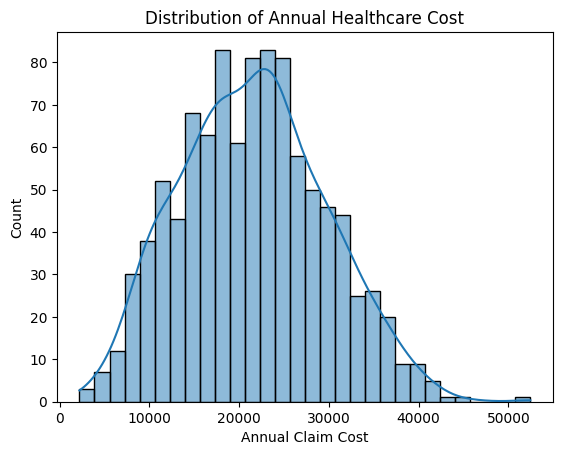

In [23]:
sns.histplot(data["annual_claim_cost"], bins=30, kde=True)
plt.title("Distribution of Annual Healthcare Cost")
plt.xlabel("Annual Claim Cost")
plt.show()

The above plot shows the distribution is right skewed with the presence of high health cost outliers.

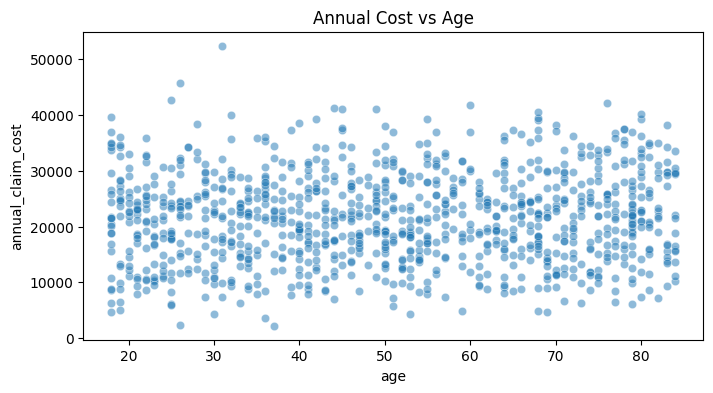

In [27]:
plt.figure(figsize=(8,4))
sns.scatterplot(x="age", y="annual_claim_cost", data=data, alpha=0.5)
plt.title("Annual Cost vs Age")
plt.show()


Health cost increases with age.

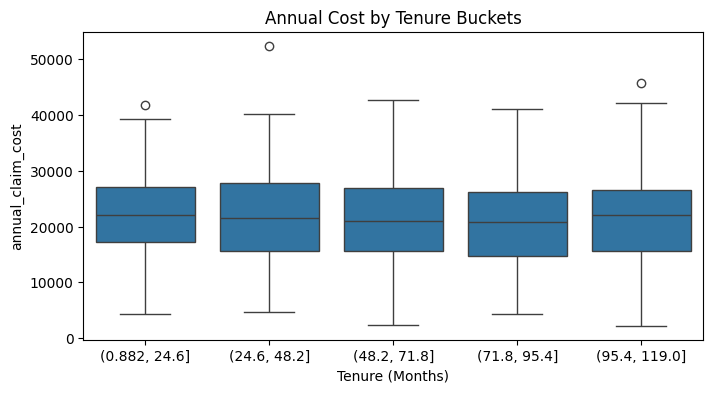

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(x=pd.cut(data["tenure_months"], bins=5), y="annual_claim_cost", data=data)
plt.title("Annual Cost by Tenure Buckets")
plt.xlabel("Tenure (Months)")
plt.show()

Longer-tenured members often have higher costs. Could reflect aging-in-place or chronic care

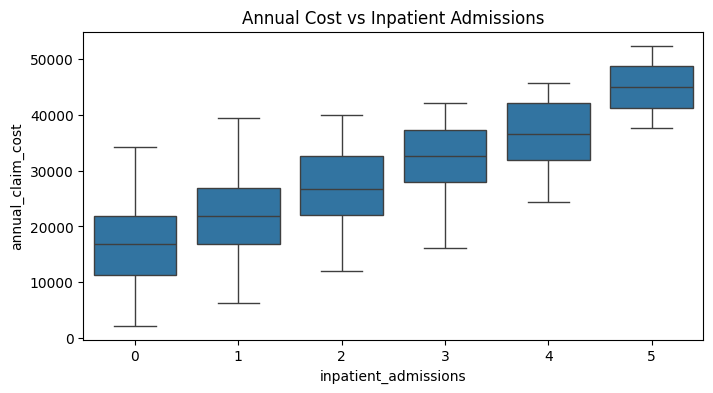

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(x="inpatient_admissions", y="annual_claim_cost", data=data)
plt.title("Annual Cost vs Inpatient Admissions")
plt.show()


Even 1–2 admissions massively increase cost. Strong justification for care management programs.

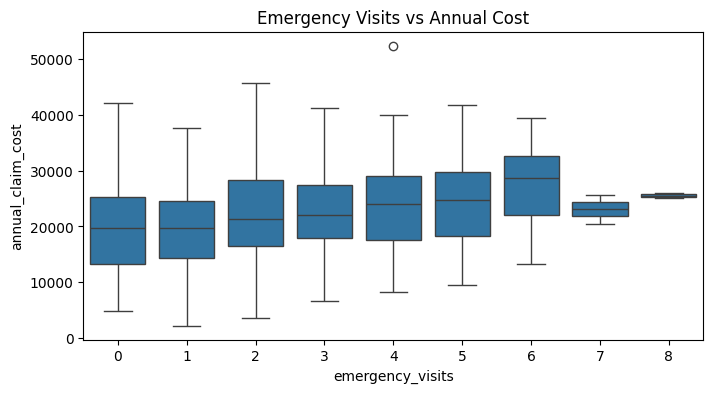

In [44]:
plt.figure(figsize=(8,4))
sns.boxplot(x="emergency_visits", y="annual_claim_cost", data=data)
plt.title("Emergency Visits vs Annual Cost")
plt.show()

Emergency utilization correlates with higher cost. Indicates poor preventive care.

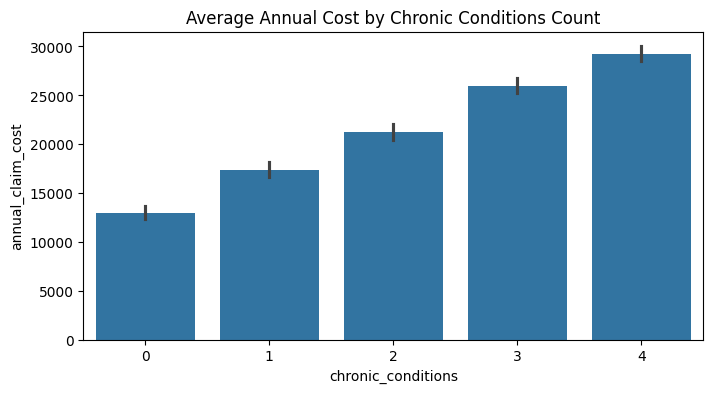

In [31]:
plt.figure(figsize=(8,4))
sns.barplot(x="chronic_conditions", y="annual_claim_cost", data=data, estimator=np.mean)
plt.title("Average Annual Cost by Chronic Conditions Count")
plt.show()

A clear increase, indicates chronic diseases burdens annual cost.

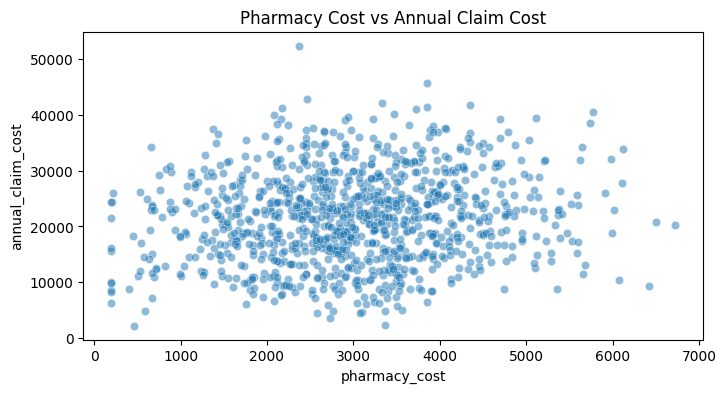

In [39]:
plt.figure(figsize=(8,4))
sns.scatterplot(
    x="pharmacy_cost",
    y="annual_claim_cost",
    data=data,
    alpha=0.5
)
plt.title("Pharmacy Cost vs Annual Claim Cost")
plt.show()

A strong linear relationship, indicates pharmacy cost as a major cost component.

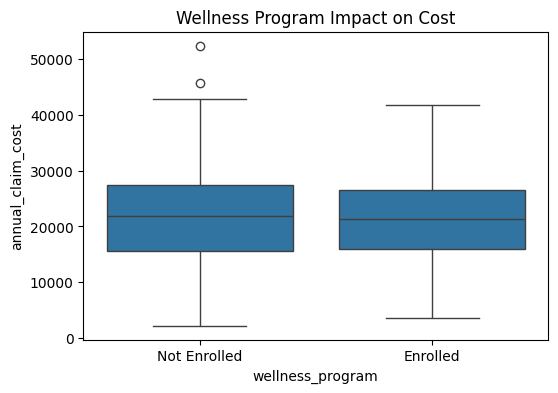

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x="wellness_program", y="annual_claim_cost", data=data)
plt.xticks([0,1], ["Not Enrolled", "Enrolled"])
plt.title("Wellness Program Impact on Cost")
plt.show()


Members enrolled in wellness programs show lower average costs.

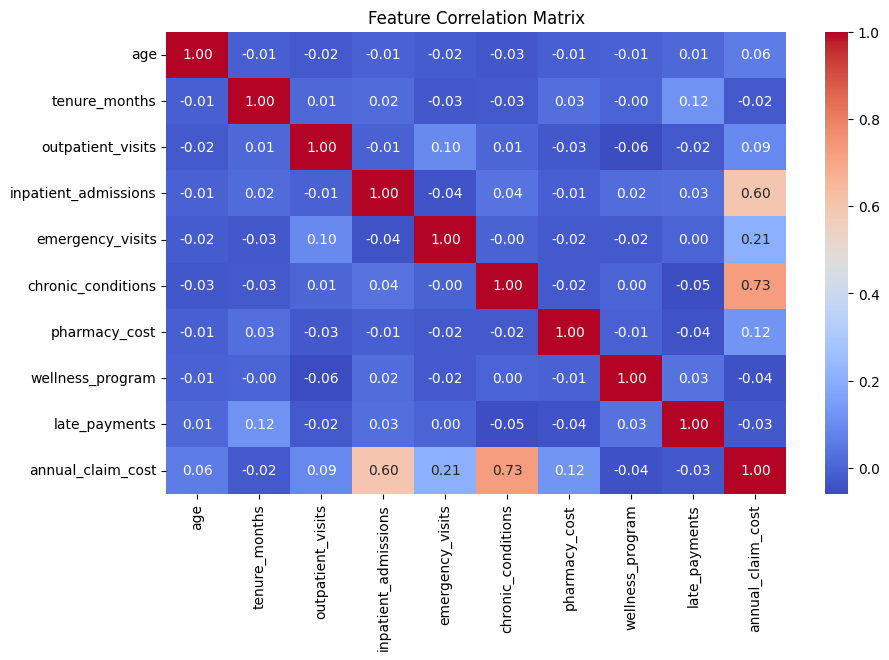

In [45]:
## checking corelation among features.
plt.figure(figsize=(10,6))
sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()


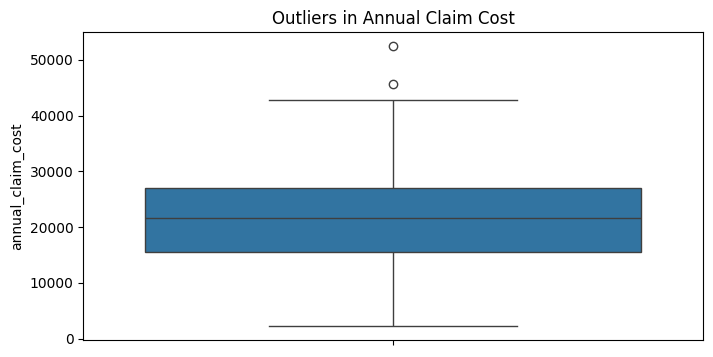

In [46]:
plt.figure(figsize=(8,4))
sns.boxplot(y=data["annual_claim_cost"])
plt.title("Outliers in Annual Claim Cost")
plt.show()


Healthcare costs naturally have extreme outliers; we retain them due to business importance.

### Data Preprocessing

In [47]:
## Splitting the dataset into training and test data
X = data.drop("annual_claim_cost", axis=1)
y = data["annual_claim_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
## Standardization

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Model and Metrics Evaluation

In [50]:
## Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))


MAE: 1516.1758373573434
R2: 0.950450590965185


In [52]:
## Ridge regression - Penalizes large coefficients and Handles multicollinearity well

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("Ridge R2:", r2_score(y_test, y_pred_ridge))


Ridge MAE: 1515.9772278332352
Ridge R2: 0.9504564881111643


In [53]:
 ## Lasso Regression - Feature selection and shrinks some coefficients to zero

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Lasso MAE: 1516.1558632094536
Lasso R2: 0.9504513335142194


In [54]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": lr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

coef_df


,Feature,Linear,Ridge,Lasso
0,age,778.636905,777.409370,778.530287
1,tenure_months,-130.481729,-130.383756,-130.370430
2,outpatient_visits,551.756893,550.980036,551.661404
3,inpatient_admissions,4586.033584,4580.427927,4585.927598
4,emergency_visits,1870.759465,1868.123859,1870.657508
5,chronic_conditions,5710.109537,5703.103785,5710.004099
6,pharmacy_cost,1270.284681,1268.215434,1270.161350
7,wellness_program,-371.302108,-370.643058,-371.199097
8,late_payments,59.981292,59.633198,59.859076


### Conclusion

Inpatient admissions and chronic conditions are the strongest drivers of annual healthcare cost, while wellness program participation shows a cost-reducing effect.